# $$\Huge{\text{Algoritmos de clustering}}$$

$$\Huge{\text{K - Means}}$$



---


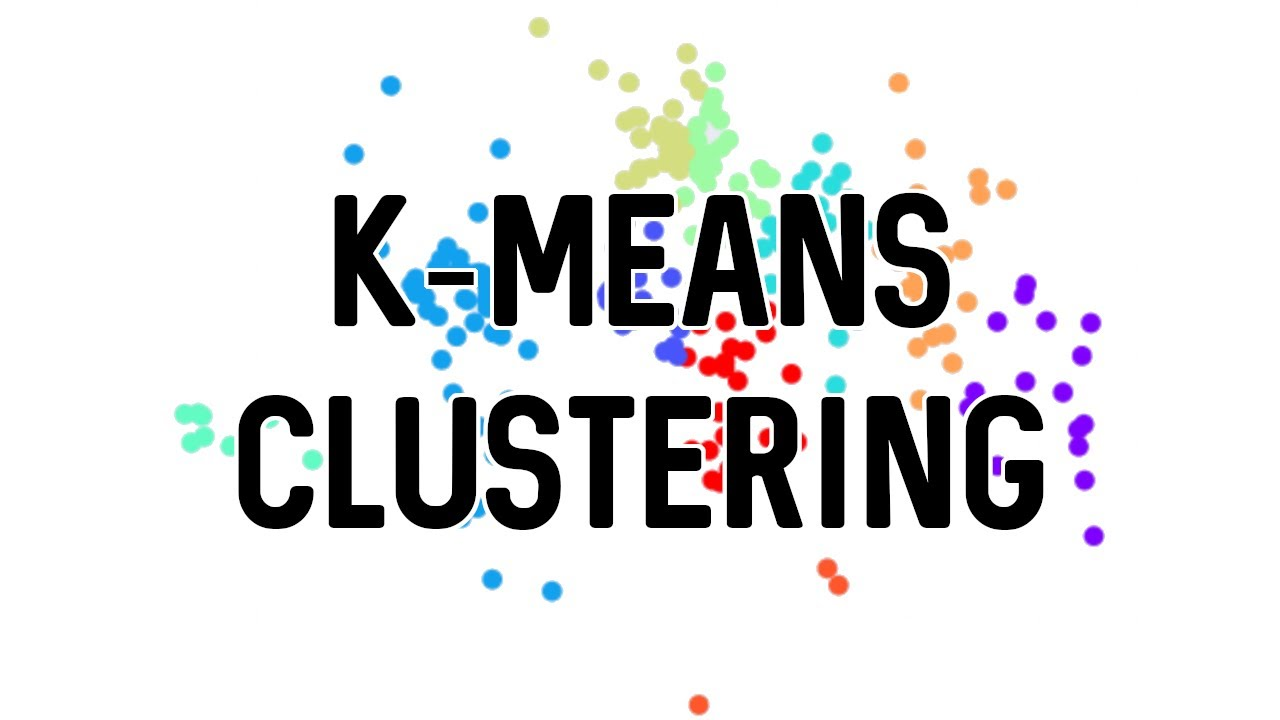


---

**Dataset**: Datos de segmentación de clientes del centro comercial.

Este dataset se usa para segmentar clientes según datos como edad, género, ingresos y nivel de gasto. Su objetivo es identificar grupos de clientes para apoyar estrategias de marketing.

**Link**: https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python?resource=download


# ***BY:***
1. Lyan Nahely Angomas pacheco
2. Eimy Karolina Genao Garcia
3. Robert Yarel Zapata Linares
4. Lisandro Mercedes De La Cruz

#Imports

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

#Carga de datos y detalles

In [ ]:
df = pd.read_csv("Mall_Customers.csv")
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None


#Seleccion de variables y normalizacion

In [ ]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Metodo del codo - eleccion k optimo

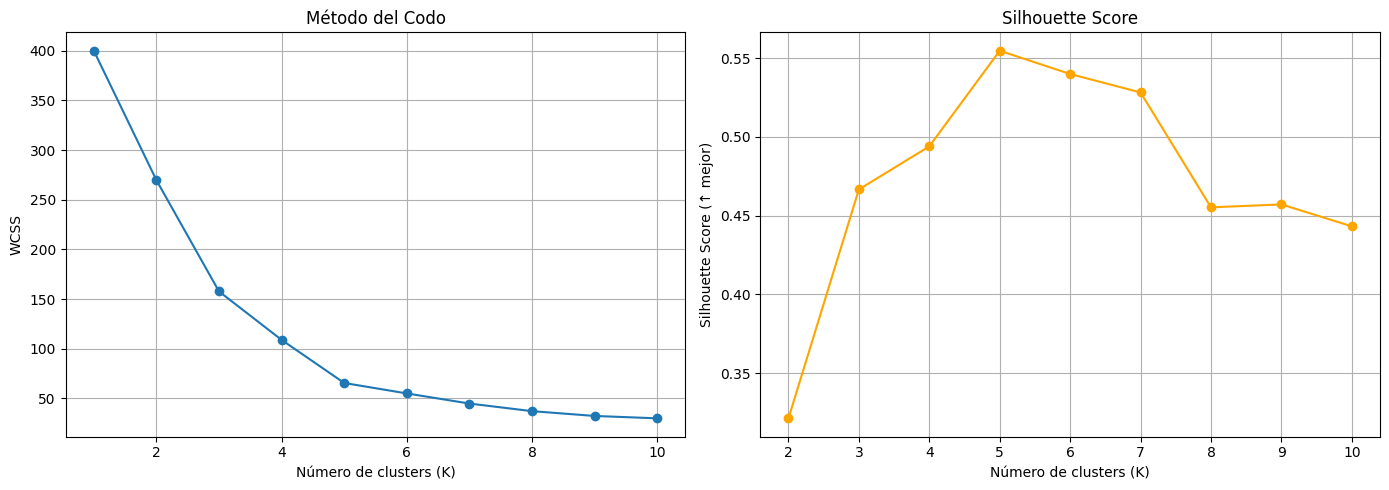

Silhouette Score por K:
  K=2: 0.3213
  K=3: 0.4666
  K=4: 0.4939
  K=5: 0.5547
  K=6: 0.5399
  K=7: 0.5281
  K=8: 0.4552
  K=9: 0.4571
  K=10: 0.4432


In [ ]:
wcss = []
silhouettes = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    if i >= 2:
        silhouettes.append(silhouette_score(X_scaled, kmeans.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, 11), wcss, marker='o')
axes[0].set_title("Método del Codo")
axes[0].set_xlabel("Número de clusters (K)")
axes[0].set_ylabel("WCSS")
axes[0].grid(True)

axes[1].plot(range(2, 11), silhouettes, marker='o', color='orange')
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Número de clusters (K)")
axes[1].set_ylabel("Silhouette Score (↑ mejor)")
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"Silhouette Score por K:")
for k, s in zip(range(2, 11), silhouettes):
    print(f"  K={k}: {s:.4f}")

#Entrenamiento k means

In [ ]:
kmeans = KMeans(n_clusters=5, init='k-means++', n_init=10, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

#Asignacion clusters a dataset

In [ ]:
df['Cluster'] = clusters
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4
...,...,...,...,...,...,...
195,196,Female,35,120,79,1
196,197,Female,45,126,28,3
197,198,Male,32,126,74,1
198,199,Male,32,137,18,3


#Visualizacion

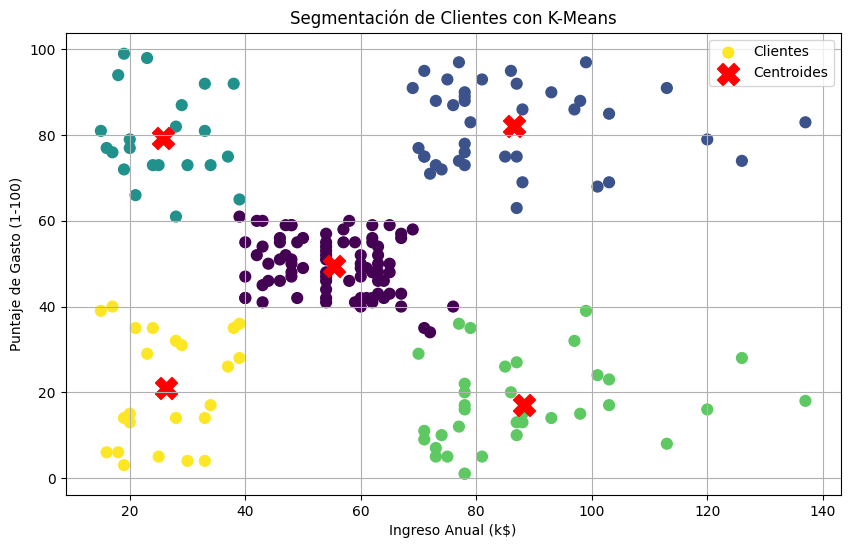

In [ ]:
centroides = scaler.inverse_transform(kmeans.cluster_centers_)

plt.figure(figsize=(10,6))

plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster'],
    cmap='viridis',
    s=60,
    label='Clientes'
)

plt.scatter(
    centroides[:, 0],
    centroides[:, 1],
    c='red',
    s=250,
    marker='X',
    label='Centroides'
)

plt.title("Segmentación de Clientes con K-Means")
plt.xlabel("Ingreso Anual (k$)")
plt.ylabel("Puntaje de Gasto (1-100)")
plt.legend()
plt.grid(True)
plt.show()

 Amarillo — bajo ingreso, bajo gasto

 Verde — alto ingreso, bajo gasto

 Morado — ingreso medio, gasto medio

 Azul — alto ingreso, alto gasto

 Teal — bajo ingreso, alto gasto